In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import make_pipeline

import numpy as np
import seaborn as sns
import pandas as pd
import sys
import os
import shap
import sys
import os

In [56]:
sys.path.insert(0, os.path.abspath(".."))
from src.pipeline import run_etl
from src.pipeline import DOMINIOS
from src.modeling import seed, scoring, train_model
df_tabla_0_imp, df_tabla_1_imp, df = run_etl("./../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [4]:
#Aplicando PCA
pca_pipeline = make_pipeline(StandardScaler(), PCA())
pca_pipeline.fit(df.drop(columns=['sheet_name','dc']))

pca_model = pca_pipeline.named_steps['pca']
pca_model.components_.shape

(10, 10)

Porcentaje de varianza explicada acumulada de todos los componentes:


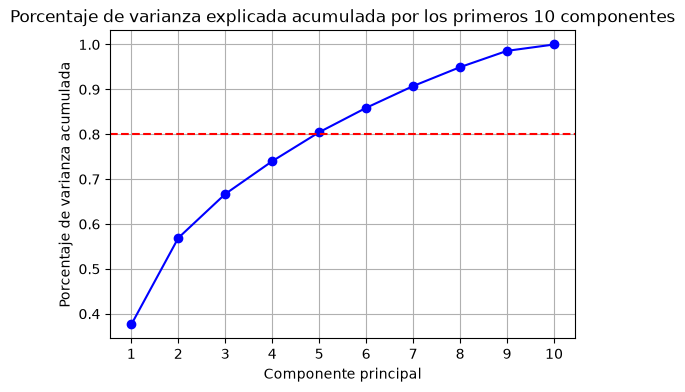

In [5]:
# Número de componentes a mostrar
n_componentes = pca_model.components_.shape[0]
# Calcular la varianza explicada acumulada sólo para los primeros 10 componentes 
prop_varianza_acum = pca_model.explained_variance_ratio_[:n_componentes].cumsum() 
print('Porcentaje de varianza explicada acumulada de todos los componentes:')

# Gráfico: Porcentaje de varianza explicada acumulada de los componentes 
plt.figure(figsize=(6, 4)) 
plt.plot(np.arange(n_componentes) + 1, prop_varianza_acum, marker='o', linestyle='-', 
color='b') 
plt.title(f'Porcentaje de varianza explicada acumulada por los primeros {n_componentes} componentes') 
plt.xlabel('Componente principal') 
plt.ylabel('Porcentaje de varianza acumulada') 
plt.xticks(np.arange(1, n_componentes + 1))  # Asegura que los valores del eje X sean del 1 al 10 
plt.axhline(y=0.80, color='r', linestyle='--', label='100% varianza explicada')
plt.grid(True) 
plt.show() 

In [6]:
print(f'Varianza explicada acomulada con 6 componentes principales: {prop_varianza_acum[6]:.3f}')

Varianza explicada acomulada con 6 componentes principales: 0.907


In [7]:
n_components = 6
# Aseguramos que los datos estén correctamente en formato numpy sin perder los nombres de columna 
df_numpy = df.drop(columns=['sheet_name','dc']).to_numpy() 
# Ajustamos el modelo PCA 
pca_model.fit(df_numpy) 
# Realizamos la transformación de los primeros 2 componentes, es decir, las proyecciones
projections = pca_model.transform(df_numpy) 
# Creamos el DataFrame de las proyecciones con nombres de las columnas 
projections_df = pd.DataFrame( 
    data=projections[:, :n_components], 
    columns=[f'PC{i+1}' for i in range(n_components)] 
) 
projections_df.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6
0,-10.809399,1.230713,0.179943,-0.557903,-0.251960,0.141013
1,-8.809766,1.160736,0.308156,-0.496059,-0.324484,0.191811
2,1.227511,0.052519,1.606874,2.281163,0.781943,0.385128
3,-17.766950,-0.444434,0.784284,1.413795,-0.071072,-0.627107
4,-10.806109,1.070416,0.226909,-0.546282,-0.375505,-0.039388
5,-4.789877,0.618672,0.776318,0.798969,-0.655576,0.215208
6,1.191748,1.348248,0.046944,-0.830637,-0.325516,-0.174845
7,-8.795431,0.638308,0.687144,0.107179,-0.297824,-0.525677
8,-4.806893,1.120909,0.572617,0.607004,-0.152689,0.260921
9,-1.817689,1.589980,0.331337,-0.646752,-0.124671,0.002071


In [8]:
projections_df['dc'] = df['dc'].values

In [9]:
projections_df

,PC1,PC2,PC3,PC4,PC5,PC6,dc
0,-10.809399,1.230713,0.179943,-0.557903,-0.251960,0.141013,0
1,-8.809766,1.160736,0.308156,-0.496059,-0.324484,0.191811,0
2,1.227511,0.052519,1.606874,2.281163,0.781943,0.385128,2
3,-17.766950,-0.444434,0.784284,1.413795,-0.071072,-0.627107,1
4,-10.806109,1.070416,0.226909,-0.546282,-0.375505,-0.039388,0
...,...,...,...,...,...,...,...
112,1.247792,0.675357,-0.596664,-0.139270,-0.044844,-0.372001,1
113,4.284365,-0.163916,-0.783252,-0.064223,-0.072097,-0.334041,1
114,14.337918,-1.367963,-0.767776,0.638931,0.136649,-0.043376,2
115,-5.740899,0.388743,-0.740958,0.014169,0.169725,0.106425,0


In [42]:
models = {
    'SVC LINEAR': SVC(kernel='linear', class_weight='balanced', C=0.1, gamma='scale', random_state=seed),
    'RF': RandomForestClassifier(max_depth=4, n_estimators=200, min_samples_leaf=1, class_weight='balanced', max_features='sqrt', random_state=seed),
    'SVC RBF': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=seed),
    'GB': GradientBoostingClassifier(learning_rate=0.1, max_depth=2,max_features='sqrt',min_samples_leaf=10, n_estimators=100, subsample=0.7, random_state=seed),
}

In [58]:
score_pca = train_model(models['SVC LINEAR'], projections_df.drop(columns=['dc']), projections_df['dc'], cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=seed))

score_no_pca = train_model(models['SVC LINEAR'], df.drop(columns=['sheet_name','dc']), df['dc'], cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=seed))

In [59]:
print(f'score_pca[\'train_f1_macro\'].mean(): {score_pca['train_f1_macro'].mean()}')
print(f'score_no_pca[\'train_f1_macro\'].mean(): {score_no_pca['train_f1_macro'].mean()}')

score_pca['train_f1_macro'].mean(): 0.7989494043226053
score_no_pca['train_f1_macro'].mean(): 0.8498104035936295
